In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler

In [15]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [16]:
print("Danh sách các đặc trưng:")
print(iris.feature_names)

print("\nDanh sách các nhãn:")
print(iris.target_names)

print("\nThông tin dataset:")
df.info()

Danh sách các đặc trưng:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Danh sách các nhãn:
['setosa' 'versicolor' 'virginica']

Thông tin dataset:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


## Yêu cầu 2: Tính trung bình, độ lệch chuẩn của từng đặc trưng

In [17]:
# Lấy các cột đặc trưng (không bao gồm species)
features = df.drop("species", axis=1)

# Tính trung bình của từng đặc trưng
print("Trung bình (Mean) của từng đặc trưng:")
print("="*50)
means = features.mean()
for feature, mean_val in means.items():
    print(f"{feature:25s}: {mean_val:.4f}")

print("\n" + "="*50)

# Tính độ lệch chuẩn của từng đặc trưng
print("\nĐộ lệch chuẩn (Standard Deviation) của từng đặc trưng:")
print("="*50)
stds = features.std()
for feature, std_val in stds.items():
    print(f"{feature:25s}: {std_val:.4f}")

Trung bình (Mean) của từng đặc trưng:
sepal length (cm)        : 5.8433
sepal width (cm)         : 3.0573
petal length (cm)        : 3.7580
petal width (cm)         : 1.1993


Độ lệch chuẩn (Standard Deviation) của từng đặc trưng:
sepal length (cm)        : 0.8281
sepal width (cm)         : 0.4359
petal length (cm)        : 1.7653
petal width (cm)         : 0.7622


In [18]:
# Hiển thị thống kê mô tả chi tiết
print("Thống kê mô tả chi tiết của các đặc trưng:")
print("="*50)
features.describe()

Thống kê mô tả chi tiết của các đặc trưng:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


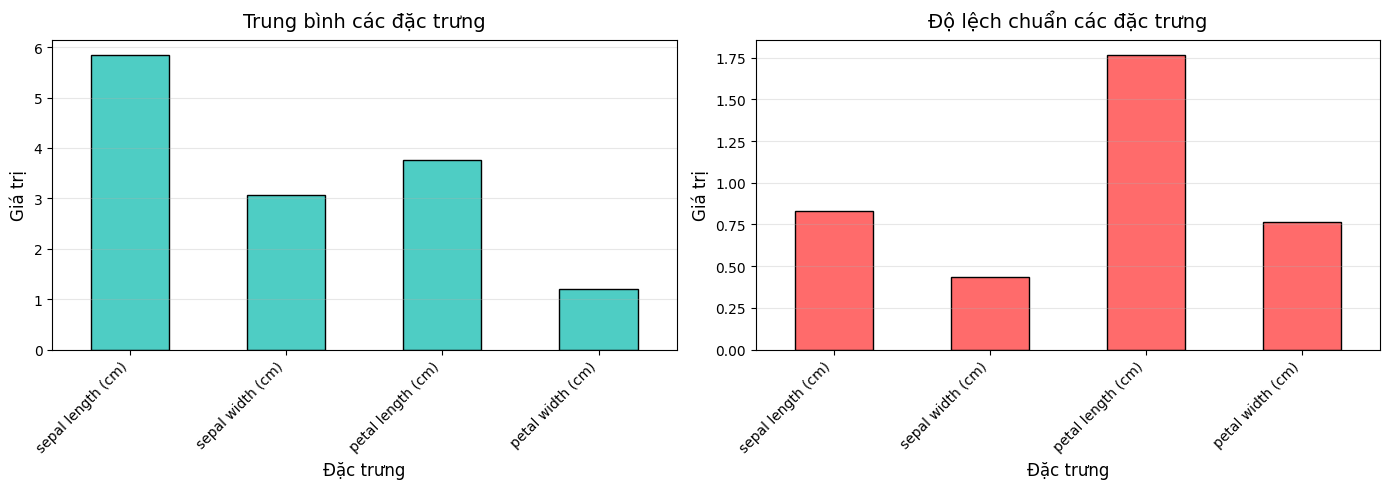

In [19]:
# Vẽ biểu đồ so sánh trung bình và độ lệch chuẩn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ Mean
means.plot(kind='bar', ax=axes[0], color='#4ECDC4', edgecolor='black')
axes[0].set_title('Trung bình các đặc trưng', fontsize=14, pad=10)
axes[0].set_ylabel('Giá trị', fontsize=12)
axes[0].set_xlabel('Đặc trưng', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# Biểu đồ Std
stds.plot(kind='bar', ax=axes[1], color='#FF6B6B', edgecolor='black')
axes[1].set_title('Độ lệch chuẩn các đặc trưng', fontsize=14, pad=10)
axes[1].set_ylabel('Giá trị', fontsize=12)
axes[1].set_xlabel('Đặc trưng', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
#Yêu cầu 3
# %%
species_mapping = {
    0: "setosa",
    1: "versicolor",
    2: "virginica"
}

df["species_name"] = df["species"].map(species_mapping)

Đang vẽ pairplot...


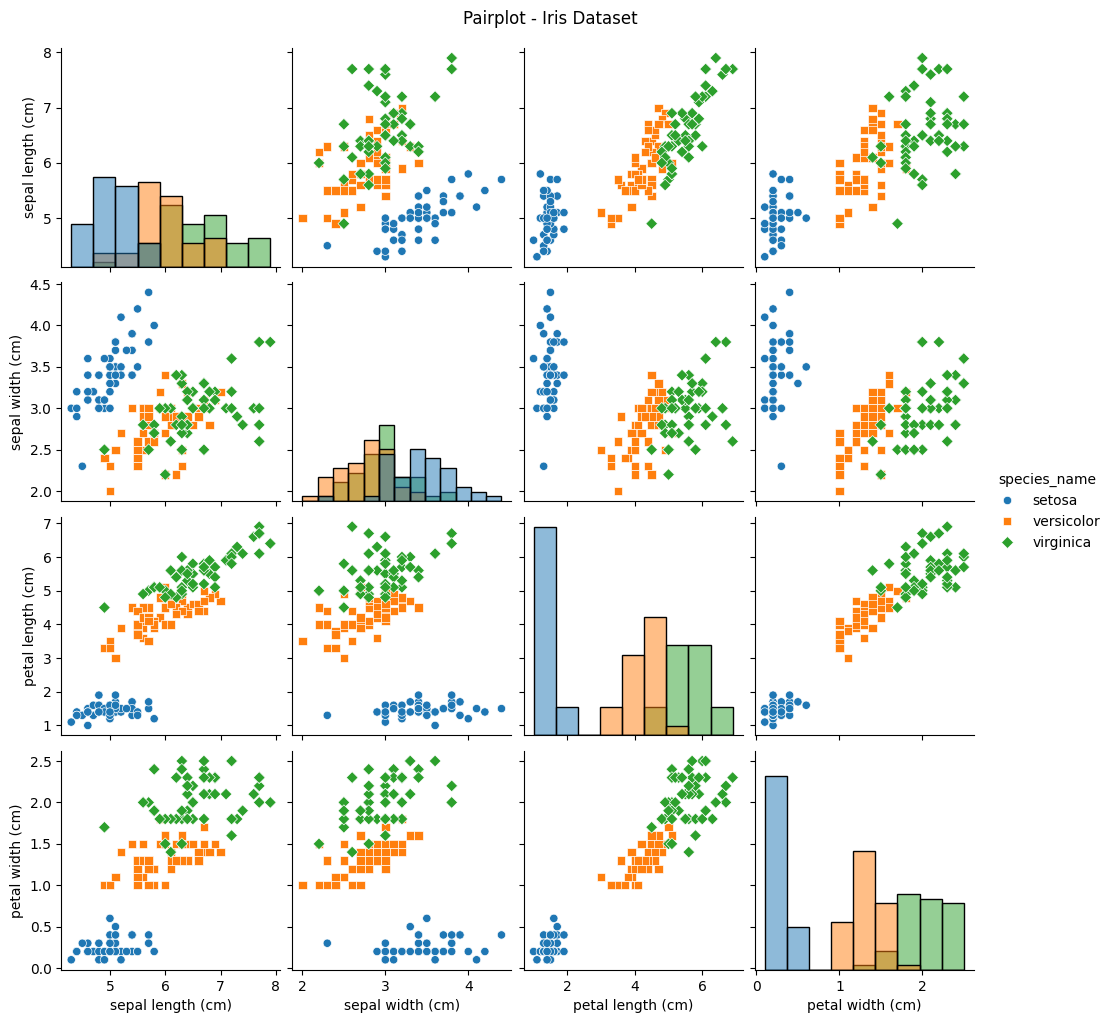

In [21]:
# %%
print("Đang vẽ pairplot...")

pairplot = sns.pairplot(
    df,
    hue="species_name",
    vars=iris.feature_names,
    diag_kind="hist",
    markers=["o", "s", "D"]
)

pairplot.fig.suptitle(
    "Pairplot - Iris Dataset",
    y=1.02
)

plt.show()

In [22]:
# %%
correlation_matrix = df[iris.feature_names].corr()

print("Ma trận tương quan:")
print(correlation_matrix)

Ma trận tương quan:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


In [23]:
# %%
print("Các cặp tương quan mạnh nhất:")

corr_pairs = []

for i in range(len(iris.feature_names)):
    for j in range(i+1, len(iris.feature_names)):
        corr = correlation_matrix.iloc[i, j]
        corr_pairs.append(
            (iris.feature_names[i], iris.feature_names[j], abs(corr), corr)
        )

corr_pairs.sort(key=lambda x: x[2], reverse=True)

for pair in corr_pairs[:3]:
    print(pair[0], "và", pair[1], ":", pair[3])

Các cặp tương quan mạnh nhất:
petal length (cm) và petal width (cm) : 0.962865431402796
sepal length (cm) và petal length (cm) : 0.8717537758865838
sepal length (cm) và petal width (cm) : 0.8179411262715758


In [24]:
#Yêu cầu 4
scaler = MinMaxScaler()

X = df.drop(["species", "species_name"], axis=1)

X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=X.columns)

df_scaled.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667
